In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
class ToySimulator:
    
    def __init__(self, edge_list, theta, force_node_1 = False):
        
        self.theta = theta
        self.edge_list = edge_list
        
        self.eta_plus = theta[0]
        self.eta_minus = theta[1]
        self.lambda_plus = theta[2]
        self.lambda_minus = theta[3]
        self.gamma_plus = theta[4]
        self.gamma_minus = theta[5]
        
        self.force_node_1 = force_node_1
        
    def simulate(self, n_samples):
        
        e_ix = np.random.randint(0, len(self.edge_list), n_samples)
        e = self.edge_list[e_ix[0]]
        
        q = e[0] / (e[0] + e[1])
        
        e_ = [0, 0]
        
        if self.force_node_1:
            z_u = 1 
        
        else:
            z_u = np.random.choice([0, 1], p = [q, 1-q])
        
        e_[  z_u] += 1 + np.random.binomial(e[z_u] - 1, self.eta_plus)
        e_[1-z_u] +=     np.random.binomial(e[1-z_u],   self.eta_minus)
        
        e_[  z_u] += np.random.poisson(self.lambda_plus  + self.gamma_plus)
        e_[1-z_u] += np.random.poisson(self.lambda_minus + self.gamma_minus)
        
        self.edge_list += [e_]    
    
    def get_joint_counts(self): 
        
        max_1 = max([e[0] for e in self.edge_list])
        max_2 = max([e[1] for e in self.edge_list])
        max_all = max(max_1, max_2)
        
        joint_counts = np.zeros((max_all+1, max_all+1))
        for e in self.edge_list:
            joint_counts[e[0], e[1]] += 1
        
        return joint_counts
    
    def get_proportions(self): 
        k_1 = sum(e[0] for e in self.edge_list)/len(self.edge_list)
        k_2 = sum(e[1] for e in self.edge_list)/len(self.edge_list)
        return k_1, k_2
    
    def get_moments(self, last = None):
        
        if last is None:
            last = 0
        k_1 = [e[0] for e in self.edge_list[-last:]]
        k_2 = [e[1] for e in self.edge_list[-last:]]
        return np.mean(k_1), np.mean(k_2), np.var(k_1), np.var(k_2)
    

In [87]:
TS = ToySimulator(edge_list = [[5,2]], theta = [0.8, 0.2, 1.0, 0.5, 0.1, 0.1], force_node_1 = True)
for _ in range(10000):
    TS.simulate(1)

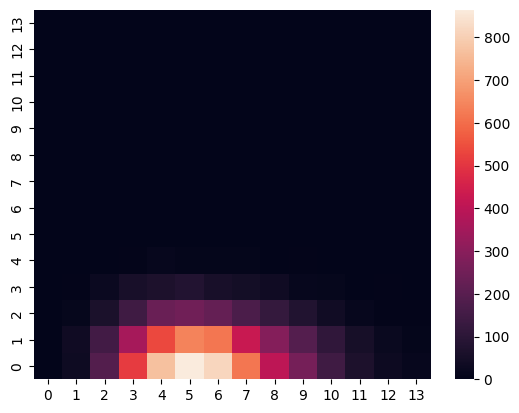

In [88]:
C = TS.get_joint_counts()

ax = sns.heatmap(C)
ax.invert_yaxis()

ax.set(xlim=(0, 14), ylim=(0, 14))
plt.show()

In [89]:
TS.get_moments()

(np.float64(0.768023197680232),
 np.float64(5.682631736826317),
 np.float64(0.7927021116506487),
 np.float64(4.911776135655108))

KeyboardInterrupt: 

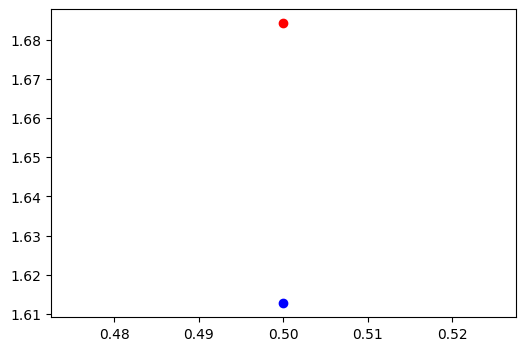

In [73]:
A = np.linspace(0.5, 1, 20)

n_reps = 10

fig, ax = plt.subplots(1, 1, figsize = (6,4))

for a in A:
    
    K_1 = []
    K_2 = []
    
    for _ in range(n_reps):
        
        TS = ToySimulator(edge_list = [[5,5]], theta = [a, 1-a, a, 1-a, 0.05, 0.05])
        for _ in range(10000):
            TS.simulate(1)
        k_1, k_2 = TS.get_proportions()
        k_1, k_2 = sorted([k_1, k_2])
        K_1 += [k_1]
        K_2 += [k_2]
        
    k_1 = np.mean(K_1)
    k_2 = np.mean(K_2)
    ax.plot(a, k_1, 'bo')
    ax.plot(a, k_2, 'ro')

### Basic Version with No Choice of $u$

/tmp/ipykernel_392476/1205387734.py:45: RuntimeWarning: divide by zero encountered in divide
  EK_1 = (1 + THETA[2] + THETA[4] - THETA[0]) / (1 - THETA[0])
/tmp/ipykernel_392476/1205387734.py:53: RuntimeWarning: invalid value encountered in multiply
  VK_1 = (THETA[0]*(1-THETA[0])*EK_1 - THETA[0]*(1-THETA[0]) +  THETA[2] + THETA[4]) / (1 - THETA[0]**2)


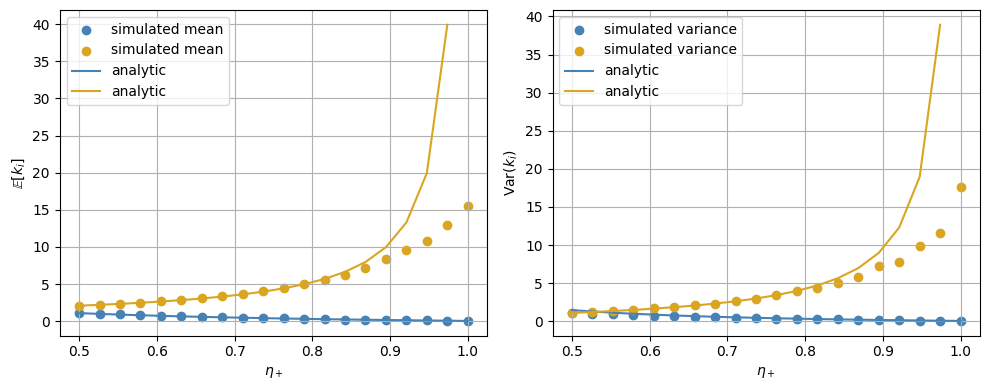

In [99]:
A = np.linspace(0.5, 1, 20)

n_reps = 10

fig, ax = plt.subplots(1, 2, figsize = (10,4))

THETA = [A, 1-A, A, 1-A, 0.05, 0.05]

for i in range(len(A)):
        
    MU_1 = []
    MU_2 = []
    VAR_1 = []
    VAR_2 = []
    
    for _ in range(n_reps):
        
        theta = [THETA[0][i], THETA[1][i], THETA[2][i], THETA[3][i], THETA[4], THETA[5]]
        
        TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_node_1 = True)
        for _ in range(10000):
            TS.simulate(1)
        mu_1, mu_2, var_1, var_2 = TS.get_moments(last = 1000)
    
        MU_1 += [mu_1]
        MU_2 += [mu_2]
        VAR_1 += [var_1]
        VAR_2 += [var_2]
    
    k_1 = np.mean(MU_1)
    k_2 = np.mean(MU_2)
    v_1 = np.mean(VAR_1)
    v_2 = np.mean(VAR_2)
    
    a = A[i]
    ax[0].scatter(a, k_1, marker = 'o', color = "steelblue", label = "simulated mean" if i == 0 else "")
    ax[0].scatter(a, k_2, marker = 'o', color = "goldenrod", label = "simulated mean" if i == 0 else "")
    
    ax[1].scatter(a, v_1,  color = "steelblue", label = "simulated variance" if i == 0 else "")
    ax[1].scatter(a, v_2,  color = "goldenrod", label = "simulated variance" if i == 0 else "")
    
# analytic approximations

EK_0 = (THETA[3] + THETA[5]) / (1 - THETA[1])
EK_1 = (1 + THETA[2] + THETA[4] - THETA[0]) / (1 - THETA[0])

ax[0].plot(A, EK_0,  label = 'analytic', color = "steelblue")
ax[0].plot(A, EK_1,  label = 'analytic', color = "goldenrod")

VK_0 = (THETA[1]*EK_0 + THETA[3] + THETA[5]) / (1 - THETA[1]**2)
ax[1].plot(A, VK_0,  label = 'analytic', color = "steelblue")

VK_1 = (THETA[0]*(1-THETA[0])*EK_1 - THETA[0]*(1-THETA[0]) +  THETA[2] + THETA[4]) / (1 - THETA[0]**2) 


ax[1].plot(A, VK_1, label = 'analytic', color = "goldenrod")

for i in [0,1]:
    ax[i].set_xlabel(r'$\eta_+$')
    # ax[i].set_xlim(0.5, 1)
    # ax[i].set_ylim(0, 10)
    ax[i].grid()
    # ax[i].semilogy()   
    
ax[0].set_ylabel(r'$\mathbb{E}[k_i]$')
ax[1].set_ylabel(r'$\mathrm{Var}(k_i)$') 
ax[0].legend()
ax[1].legend()

plt.tight_layout()

Confusingly, this simple approach based on assuming that everything is independent Poissons when we choose exclusively $z_u = 1$ works reasonably well for everything except the dispersion of $K_1$, which feels surprising. Perhaps even more surprising, the problem is that we are *over*estimating the dispersion with the approximation, which is quite surprising indeed. 